# scOPE end-to-end — CRC (TCGA-COAD + TCGA-READ)

Two-phase scOPE workflow applied to colorectal cancer:

1. **Phase 1** — learn a latent space from TCGA COAD+READ bulk RNA-seq and train
   mutation classifiers (APC, KRAS, TP53, PIK3CA, SMAD4, …).
2. **Phase 2** — project Lee et al. 2020 CRC scRNA-seq (GSE132465, ~64 K cells,
   23 patients) into the bulk latent space and infer per-cell mutation probabilities.

**Data notes:**
- Bulk expression: UCSC Xena TCGA COAD + READ `HiSeqV2_PANCAN`
  (log₂(norm_count + 1), genes × samples).  Both primary tumour (sample type `01`)
  and matched normal (sample type `11`) samples are loaded.
- Mutations: TCGA MC3 PanCanAtlas MAF (`mc3.v0.2.8.PUBLIC.xena.gz`) from the
  Xena pancanatlas hub — one file for all 33 cancer types, filtered to CRC by
  TSS code.  Barcodes trimmed to 15 chars to match Xena expression IDs.
- Normal samples receive all-zero mutation labels so the classifier has an
  explicit wild-type colon reference class, sharpening tumour-specific signals.
- scRNA-seq: Lee et al. 2020 GSE132465 raw UMI count matrix (genes × cells,
  `.txt.gz`, tab-separated) downloaded via the GEO HTTP endpoint.


## 1. Imports & paths

In [1]:
import os

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import requests

from scope import BulkPipeline, SingleCellPipeline
from scope.visualization import (
    compute_umap,
    plot_mutation_probabilities,
    plot_scree,
    plot_mutation_heatmap,
)


In [2]:
# -- Paths ------------------------------------------------------------------
BASE_DIR   = "/Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data"
BULK_DIR   = os.path.join(BASE_DIR, "TCGA_CRC")
SC_DIR     = os.path.join(BASE_DIR, "CRC_scRNA")
MODELS_DIR = os.path.join(BASE_DIR, "..", "models", "CRC")

for d in [BULK_DIR, SC_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

# -- File locations ---------------------------------------------------------
coad_expr_path = os.path.join(BULK_DIR, "TCGA_COAD_HiSeqV2_PANCAN.tsv.gz")
read_expr_path = os.path.join(BULK_DIR, "TCGA_READ_HiSeqV2_PANCAN.tsv.gz")
mc3_path       = os.path.join(BULK_DIR, "mc3.v0.2.8.PUBLIC.xena.gz")
sc_matrix_path = os.path.join(SC_DIR,   "GSE132465_raw_UMI_count_matrix.txt.gz")
sc_meta_path   = os.path.join(SC_DIR,   "GSE132465_cell_annotation.txt.gz")


## 2. Download raw data

In [3]:
# -- UCSC Xena -- bulk RNA-seq expression (still publicly served) -----------
XENA_BASE = "https://tcga.xenahubs.net/download"

xena_downloads = {
    coad_expr_path : f"{XENA_BASE}/TCGA.COAD.sampleMap/HiSeqV2_PANCAN.gz",
    read_expr_path : f"{XENA_BASE}/TCGA.READ.sampleMap/HiSeqV2_PANCAN.gz",
}
for dest, url in xena_downloads.items():
    if os.path.exists(dest):
        print(f"  already present -- {os.path.basename(dest)}")
    else:
        print(f"  downloading {os.path.basename(dest)} ...")
        r = requests.get(url, stream=True, timeout=300)
        r.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in r.iter_content(1 << 20):
                fh.write(chunk)
        print(f"  done -> {dest}")


  already present -- TCGA_COAD_HiSeqV2_PANCAN.tsv.gz
  already present -- TCGA_READ_HiSeqV2_PANCAN.tsv.gz


In [4]:
# -- MC3 PanCanAtlas MAF -- all TCGA cancer types, one file (~200 MB) -------
if not os.path.exists(mc3_path):
    print("Downloading MC3 MAF (~200 MB) ...")
    r = requests.get(
        "https://pancanatlas.xenahubs.net/download/mc3.v0.2.8.PUBLIC.xena.gz",
        stream=True, timeout=600,
    )
    r.raise_for_status()
    with open(mc3_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {mc3_path}")
else:
    print(f"  already present -- {os.path.basename(mc3_path)}")


  already present -- mc3.v0.2.8.PUBLIC.xena.gz


In [5]:
# -- GEO -- Lee et al. 2020 CRC scRNA-seq (GSE132465) ----------------------
GEO_HTTP = "https://www.ncbi.nlm.nih.gov/geo/download"

sc_downloads = {
    sc_matrix_path : (
        f"{GEO_HTTP}/?acc=GSE132465&format=file"
        "&file=GSE132465%5FGEO%5Fprocessed%5FCRC%5F10X%5Fraw%5FUMI%5Fcount%5Fmatrix%2Etxt%2Egz"
    ),
    sc_meta_path : (
        f"{GEO_HTTP}/?acc=GSE132465&format=file"
        "&file=GSE132465%5FGEO%5Fprocessed%5FCRC%5F10X%5Fcell%5Fannotation%2Etxt%2Egz"
    ),
}
for dest, url in sc_downloads.items():
    if os.path.exists(dest):
        print(f"  already present -- {os.path.basename(dest)}")
    else:
        print(f"  downloading {os.path.basename(dest)} ...  (may take several minutes)")
        r = requests.get(url, stream=True, timeout=600)
        r.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in r.iter_content(1 << 20):
                fh.write(chunk)
        print(f"  done -> {dest}")


  already present -- GSE132465_raw_UMI_count_matrix.txt.gz
  already present -- GSE132465_cell_annotation.txt.gz


## 3. Load & prepare bulk RNA-seq

Xena `HiSeqV2_PANCAN` files are **genes × samples**. We load both primary tumour
(`01`) and matched normal (`11`) samples. Normal samples are included in the
training set with all-zero mutation labels, giving the classifier an explicit
wild-type colon reference. This sharpens tumour-specific mutation signals,
particularly for KRAS where normal colon has no driver mutation to express.

Sample type is tracked in `adata_bulk.obs["sample_type"]`.


In [6]:
# -- Peek at orientation ----------------------------------------------------
for label, path in [("COAD", coad_expr_path), ("READ", read_expr_path)]:
    peek = pd.read_csv(path, sep="\t", index_col=0, nrows=3)
    print(f"{label} peek : {peek.shape}  cols[:4] = {peek.columns[:4].tolist()}")


COAD peek : (3, 329)  cols[:4] = ['TCGA-CA-5256-01', 'TCGA-AZ-6599-01', 'TCGA-AA-3655-01', 'TCGA-A6-6137-01']
READ peek : (3, 105)  cols[:4] = ['TCGA-DC-6156-01', 'TCGA-DC-6160-01', 'TCGA-EI-6512-01', 'TCGA-DC-5869-01']


In [7]:
def load_xena_expression(path, cohort):
    """Load Xena HiSeqV2_PANCAN file -> samples x genes AnnData.

    Returns both tumour (01) and matched normal (11) samples.
    obs columns:  cohort, sample_type ('tumor' | 'normal')
    """
    df = pd.read_csv(path, sep="\t", index_col=0).T   # samples x genes

    tumour_mask = df.index.str[13:15] == "01"
    normal_mask = df.index.str[13:15] == "11"
    keep_mask   = tumour_mask | normal_mask
    df = df[keep_mask]

    sample_type = df.index.str[13:15].map({"01": "tumor", "11": "normal"})

    adata = ad.AnnData(
        X   = df.values.astype(np.float32),
        obs = pd.DataFrame({
            "cohort"      : cohort,
            "sample_type" : sample_type.values,
        }, index=df.index),
        var = pd.DataFrame(index=df.columns),
    )
    n_t = tumour_mask.sum()
    n_n = normal_mask.sum()
    print(f"{cohort} : {n_t} tumour + {n_n} normal = {adata.n_obs} samples x {adata.n_vars} genes")
    return adata

adata_coad = load_xena_expression(coad_expr_path, "COAD")
adata_read = load_xena_expression(read_expr_path, "READ")


COAD : 286 tumour + 41 normal = 327 samples x 20530 genes
READ : 94 tumour + 10 normal = 104 samples x 20530 genes


In [8]:
# -- Concatenate COAD + READ ------------------------------------------------
adata_bulk = ad.concat([adata_coad, adata_read], join="inner")
adata_bulk.var_names_make_unique()

print(f"Combined bulk : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(adata_bulk.obs.groupby(["cohort", "sample_type"]).size().to_string())


Combined bulk : 431 samples x 20530 genes
cohort  sample_type
COAD    normal          41
        tumor          286
READ    normal          10
        tumor           94


In [9]:
# -- Sanity check -----------------------------------------------------------
X = adata_bulk.X
print(f"NaN : {np.isnan(X).sum()} | Inf : {np.isinf(X).sum()}")
print(f"Min : {np.nanmin(X):.3f} | Max : {np.nanmax(X):.3f}")
print(f"Neg : {(X < 0).sum()}  (expected for log2 data)")


NaN : 0 | Inf : 0
Min : -9.723 | Max : 18.340
Neg : 5106685  (expected for log2 data)


## 4. Build mutation label matrix

Using the TCGA MC3 PanCanAtlas MAF filtered to CRC by TSS code.

**Normal sample strategy:**  Tumour samples get their MC3-derived binary mutation
labels.  Matched normal samples get all-zero labels — they carry no driver
somatic mutations in the colon epithelium, so every gene label is 0.  This
gives the logistic classifiers a clean negative class that is *biologically
distinct* from tumour-wild-type (i.e. a tumour where a gene happens not to be
mutated is a different expression context from normal colon tissue).

The training set therefore spans the full expression continuum:
  normal colon → tumour WT → tumour mutant


In [10]:
# -- Key CRC driver genes ---------------------------------------------------
CRC_GENES = [
    # -- WNT pathway -------------------------------------------------------
    "APC",      # ~80% CRC -- gatekeeper tumour suppressor
    "CTNNB1",   # beta-catenin hotspot
    "RNF43",    # WNT negative regulator

    # -- RAS/MAPK pathway --------------------------------------------------
    "KRAS",     # ~40% -- codons 12/13/61
    "NRAS",     # ~5%
    "BRAF",     # V600E -- MSI-H / serrated pathway
    "ERBB2",    # HER2 amplification / mutation

    # -- PI3K pathway ------------------------------------------------------
    "PIK3CA",   # ~20% -- kinase domain hotspots
    "PTEN",     # tumour suppressor

    # -- TGF-b / BMP pathway -----------------------------------------------
    "SMAD4",    # DPC4 -- metastasis-associated
    "SMAD2",
    "TGFBR2",   # frameshift in MSI tumours

    # -- DNA damage / mismatch repair --------------------------------------
    "TP53",     # ~60%
    "MLH1",     # MSI-H methylation / germline Lynch
    "MSH2",
    "MSH6",
    "PMS2",

    # -- Chromatin / epigenetic --------------------------------------------
    "ARID1A",
    "KMT2D",    # MLL2
    "KMT2C",    # MLL3
    "SETD2",

    # -- Other recurrent ---------------------------------------------------
    "FAT4",
    "FBXW7",    # NOTCH/WNT ubiquitin ligase
    "SOX9",
    "TCF7L2",
]
CRC_GENES = list(dict.fromkeys(CRC_GENES))
print(f"Targeting {len(CRC_GENES)} CRC driver genes")


Targeting 25 CRC driver genes


In [11]:
KEEP_CLASSES = {
    "Missense_Mutation", "Nonsense_Mutation", "Frame_Shift_Del",
    "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
    "Splice_Site", "Translation_Start_Site", "Nonstop_Mutation",
}


In [12]:
# -- Load MC3, filter to COAD + READ by TSS code ----------------------------
mc3 = pd.read_csv(mc3_path, sep="\t", low_memory=False)
print(f"MC3 raw : {len(mc3):,} rows   cols[:6]: {mc3.columns.tolist()[:6]}")

mc3 = mc3.rename(columns={
    "sample" : "Tumor_Sample_Barcode",
    "effect" : "Variant_Classification",
    "gene"   : "Hugo_Symbol",
})

CRC_TSS = {
    # COAD
    "AA", "AD", "AY", "AZ", "CK", "CM", "DM", "F4", "G4",
    "NH", "QG", "RU", "T9", "3L", "4N",
    # READ
    "AF", "AG", "DC", "EF", "F5", "G5", "QT",
}
tss     = mc3["Tumor_Sample_Barcode"].str.split("-").str[1]
maf_crc = mc3[tss.isin(CRC_TSS)].copy()
print(f"CRC rows (pre-filter)  : {len(maf_crc):,}   samples: {maf_crc['Tumor_Sample_Barcode'].nunique()}")

maf_crc = maf_crc[maf_crc["Variant_Classification"].isin(KEEP_CLASSES)]
maf_crc["sample_id"] = maf_crc["Tumor_Sample_Barcode"].str[:15]
maf_all = maf_crc[["sample_id", "Hugo_Symbol"]].dropna()
print(f"After coding filter    : {len(maf_all):,} variants   {maf_all['sample_id'].nunique()} samples")


MC3 raw : 2,907,335 rows   cols[:6]: ['sample', 'chr', 'start', 'end', 'reference', 'alt']
CRC rows (pre-filter)  : 170,647   samples: 257
After coding filter    : 110,033 variants   257 samples


In [13]:
# -- Build binary mutation matrix for tumour samples -----------------------
mut_matrix = (
    maf_all[["sample_id", "Hugo_Symbol"]]
    .drop_duplicates()
    .assign(mutated=1)
    .pivot_table(index="sample_id", columns="Hugo_Symbol",
                 values="mutated", fill_value=0)
)
mut_matrix.columns.name = None
mut_matrix.index.name   = None

genes_present = [g for g in CRC_GENES if g in mut_matrix.columns]
genes_missing = [g for g in CRC_GENES if g not in mut_matrix.columns]
mut_tumour    = mut_matrix[genes_present]

print(f"Tumour mutation matrix : {mut_tumour.shape}")
if genes_missing:
    print(f"Genes missing          : {genes_missing}")


Tumour mutation matrix : (257, 25)


In [14]:
# -- Intersect bulk TUMOUR samples with MC3 --------------------------------
tumour_obs  = adata_bulk.obs[adata_bulk.obs["sample_type"] == "tumor"]
normal_obs  = adata_bulk.obs[adata_bulk.obs["sample_type"] == "normal"]

bulk_t15    = pd.Index(tumour_obs.index.str[:15])
mut_15      = pd.Index(mut_tumour.index.str[:15])
shared_mask = bulk_t15.isin(mut_15)

print(f"Tumour bulk samples with MC3 calls : {shared_mask.sum()} / {len(tumour_obs)}")
assert shared_mask.sum() > 50, (
    f"Too few tumour matches ({shared_mask.sum()}) -- check barcode formats:\n"
    f"  bulk : {tumour_obs.index[:3].tolist()}\n"
    f"  MC3  : {mut_tumour.index[:3].tolist()}"
)

# Reindex MC3 to matched tumour barcodes
mut_re        = mut_tumour.copy()
mut_re.index  = mut_re.index.str[:15]
mut_re        = mut_re[~mut_re.index.duplicated(keep="first")]

matched_barcodes    = tumour_obs.index[shared_mask]
matched_barcodes_15 = matched_barcodes.str[:15]
mut_for_tumours     = mut_re.loc[matched_barcodes_15]
mut_for_tumours.index = matched_barcodes   # restore original 15-char barcodes

print(f"Normal bulk samples (all-zero labels) : {len(normal_obs)}")
print(f"\nMutation frequencies in tumour set (top 20):")
print(mut_for_tumours.sum().sort_values(ascending=False).head(20))


Tumour bulk samples with MC3 calls : 232 / 380
Normal bulk samples (all-zero labels) : 51

Mutation frequencies in tumour set (top 20):
APC       178.0
TP53      154.0
KRAS      105.0
PIK3CA     61.0
FAT4       58.0
SOX9       36.0
BRAF       32.0
FBXW7      32.0
SMAD4      32.0
KMT2D      31.0
TCF7L2     30.0
ARID1A     27.0
KMT2C      22.0
RNF43      21.0
PTEN       18.0
NRAS       18.0
CTNNB1     16.0
SETD2      15.0
MLH1       10.0
TGFBR2      9.0
dtype: float64


In [15]:
# -- Build zero-label rows for normal samples ------------------------------
mut_for_normals = pd.DataFrame(
    0,
    index   = normal_obs.index,
    columns = genes_present,
    dtype   = np.float32,
)

# -- Combine and align with adata_bulk -------------------------------------
mutation_labels = pd.concat([mut_for_tumours, mut_for_normals])

# Subset adata_bulk to only samples that have labels (matched tumours + all normals)
labeled_samples = mutation_labels.index
adata_bulk      = adata_bulk[adata_bulk.obs_names.isin(labeled_samples)].copy()
mutation_labels = mutation_labels.loc[adata_bulk.obs_names]

print(f"Final training set : {adata_bulk.n_obs} samples "
      f"({(adata_bulk.obs['sample_type']=='tumor').sum()} tumour + "
      f"{(adata_bulk.obs['sample_type']=='normal').sum()} normal)")
print(f"Mutation labels    : {mutation_labels.shape}")
mutation_labels.head()


Final training set : 283 samples (232 tumour + 51 normal)
Mutation labels    : (283, 25)


,APC,CTNNB1,RNF43,KRAS,NRAS,BRAF,ERBB2,PIK3CA,PTEN,SMAD4,...,MSH6,PMS2,ARID1A,KMT2D,KMT2C,SETD2,FAT4,FBXW7,SOX9,TCF7L2
TCGA-AZ-6599-01,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-AA-3655-01,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-CK-4952-01,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-AD-6963-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-AA-3663-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Load single-cell data

In [16]:
# -- Lee et al. 2020 GSE132465 -- raw UMI counts ---------------------------
print("Loading count matrix ... (this may take 2-5 min)")
counts = pd.read_csv(sc_matrix_path, sep="\t", index_col=0)   # genes x cells
print(f"Count matrix raw : {counts.shape}  (genes x cells)")


Loading count matrix ... (this may take 2-5 min)
Count matrix raw : (33694, 63689)  (genes x cells)


In [17]:
# -- Cell metadata ---------------------------------------------------------
meta = pd.read_csv(sc_meta_path, sep="\t", index_col=0)
print(f"Cell metadata : {meta.shape}")
print(f"Columns       : {meta.columns.tolist()}")
meta.head(3)


Cell metadata : (63689, 5)
Columns       : ['Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype']


,Patient,Class,Sample,Cell_type,Cell_subtype
Index,,,,,
SMC01-T_AAACCTGCATACGCCG,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2
SMC01-T_AAACCTGGTCGCATAT,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2
SMC01-T_AAACCTGTCCCTTGCA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2


In [18]:
# -- Build AnnData (transpose to cells x genes) ----------------------------
common_cells = counts.columns.intersection(meta.index)
print(f"Cells in both matrix and metadata : {len(common_cells)}")

adata_sc = ad.AnnData(
    X   = counts[common_cells].T.values.astype(np.float32),
    obs = meta.loc[common_cells],
    var = pd.DataFrame(index=counts.index),
)
adata_sc.var_names_make_unique()

print(f"\nSC loaded : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Patients  : {adata_sc.obs['Patient'].nunique()}")
print(f"\nCell types:")
print(adata_sc.obs["Cell_type"].value_counts().head(15))
print(f"\nClass (Tumor/Normal):")
print(adata_sc.obs["Class"].value_counts())


Cells in both matrix and metadata : 63689

SC loaded : 63689 cells x 33694 genes
Patients  : 23

Cell types:
Cell_type
T cells             23115
Epithelial cells    18539
B cells              9146
Myeloids             6769
Stromal cells        5933
Mast cells            187
Name: count, dtype: int64

Class (Tumor/Normal):
Class
Tumor     47285
Normal    16404
Name: count, dtype: int64


In [19]:
# -- QC & normalisation ----------------------------------------------------
sc.pp.filter_genes(adata_sc, min_cells=10)
sc.pp.filter_cells(adata_sc, min_genes=200)

adata_sc.obs["n_counts"] = np.asarray(adata_sc.X.sum(axis=1)).ravel()
adata_sc.obs["n_genes"]  = np.asarray((adata_sc.X > 0).sum(axis=1)).ravel()

print(f"After QC : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")

# Log-normalise to match bulk units (log2(CPM+1))
sc.pp.normalize_total(adata_sc, target_sum=1e6)   # CPM
sc.pp.log1p(adata_sc, base=2)                      # log2(CPM+1)


After QC : 63689 cells x 23075 genes


## 6. Gene overlap & sanity checks

In [20]:
overlap = set(adata_bulk.var_names) & set(adata_sc.var_names)

print(f"Bulk  : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(f"  tumor  : {(adata_bulk.obs['sample_type']=='tumor').sum()}")
print(f"  normal : {(adata_bulk.obs['sample_type']=='normal').sum()}")
print(f"SC    : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Muts  : {mutation_labels.shape}  (non-zero rows = {(mutation_labels.sum(axis=1)>0).sum()})")
print(f"Gene overlap : {len(overlap):,} / bulk={adata_bulk.n_vars} / sc={adata_sc.n_vars}")

X = adata_bulk.X
print(f"\nBulk NaN : {np.isnan(X).sum()} | Inf : {np.isinf(X).sum()}")
print(f"\nMutation frequencies in tumour samples (top 15):")
print(mutation_labels.sum().sort_values(ascending=False).head(15))
mutation_labels.head()


Bulk  : 283 samples x 20530 genes
  tumor  : 232
  normal : 51
SC    : 63689 cells x 23075 genes
Muts  : (283, 25)  (non-zero rows = 231)
Gene overlap : 15,497 / bulk=20530 / sc=23075

Bulk NaN : 0 | Inf : 0

Mutation frequencies in tumour samples (top 15):
APC       178.0
TP53      154.0
KRAS      105.0
PIK3CA     61.0
FAT4       58.0
SOX9       36.0
BRAF       32.0
FBXW7      32.0
SMAD4      32.0
KMT2D      31.0
TCF7L2     30.0
ARID1A     27.0
KMT2C      22.0
RNF43      21.0
PTEN       18.0
dtype: float64


,APC,CTNNB1,RNF43,KRAS,NRAS,BRAF,ERBB2,PIK3CA,PTEN,SMAD4,...,MSH6,PMS2,ARID1A,KMT2D,KMT2C,SETD2,FAT4,FBXW7,SOX9,TCF7L2
TCGA-AZ-6599-01,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-AA-3655-01,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-CK-4952-01,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-AD-6963-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-AA-3663-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Phase 1 — Bulk pipeline

Training set includes both tumour and matched normal samples. The normal samples
anchor the negative pole of the latent space with all-zero mutation labels,
giving classifiers cleaner decision boundaries — especially for genes like KRAS
where normal colon expression differs substantially from mutant tumour.


In [21]:
n_components = 100


In [23]:
bulk_pipe = BulkPipeline(
    norm_method         = "none",
    log1p               = False,
    center              = True,
    scale               = True,
    decomposition       = "svd",
    n_components        = n_components,
    classifier          = "logistic",
    min_positive_frac   = 0.0001,
    classifier_kwargs   = {
        "C"         : 1.0,
        "solver"    : "saga",
        "max_iter"  : 100000,
    },
)

bulk_pipe.fit(adata_bulk, mutation_labels, cv=10)
bulk_pipe.save(os.path.join(MODELS_DIR, "CRC_bulk_pipeline.pkl"))
print("Phase 1 complete -- model saved.")


18:53:21 | INFO     | scope.pipeline.bulk_pipeline — === BulkPipeline.fit ===
18:53:21 | INFO     | scope.pipeline.bulk_pipeline — Preprocessing bulk data (norm=none, log1p=False).
18:53:21 | INFO     | scope.preprocessing.bulk — BulkNormalizer fitted (method=none).
18:53:21 | INFO     | scope.preprocessing.bulk — BulkScaler fitted (center=True, scale=True).
18:53:21 | INFO     | scope.preprocessing.bulk — BulkPreprocessor fitted: 20530 genes → 20530 after filtering.
18:53:21 | INFO     | scope.pipeline.bulk_pipeline — Decomposition: svd (k=100).
18:53:21 | INFO     | scope.decomposition.svd — SVD fitted: 100 components (cumulative EVR=0.815).
18:53:21 | INFO     | scope.pipeline.bulk_pipeline — Training classifiers (logistic).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
18:53:21 | INFO     | scope.c

Phase 1 complete -- model saved.


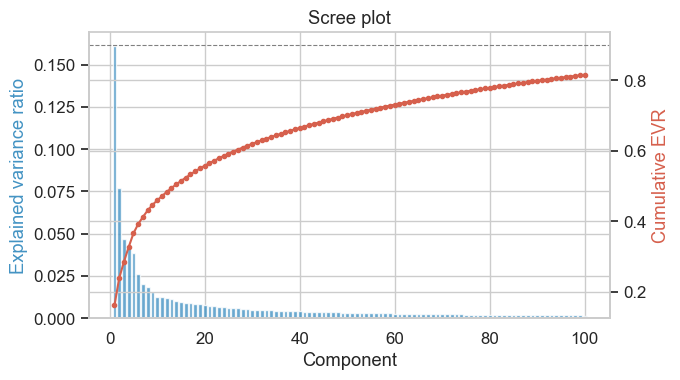

In [24]:
scree = bulk_pipe.decomposer_.scree_data()
fig, ax = plot_scree(scree, max_components=n_components)
plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, "CRC_scree.pdf"), bbox_inches="tight")
plt.show()


## 8. Phase 2 — Single-cell pipeline

In [ ]:
adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)

sc_pipe = SingleCellPipeline(
    bulk_pipeline    = bulk_pipe,
    alignment_method = "moment_matching",
)
sc_pipe.fit(adata_bulk_pp, adata_sc)
adata_sc = sc_pipe.transform(adata_sc)

mut_prob_cols = [c for c in adata_sc.obs.columns if c.startswith("mutation_prob_")]
print(f"Inferred mutation probability columns ({len(mut_prob_cols)}): {mut_prob_cols[:6]} ...")


18:54:35 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.fit ===
18:54:35 | INFO     | scope.preprocessing.single_cell — SingleCellPreprocessor fitted.
18:54:56 | INFO     | scope.utils.gene_utils — Gene universe: 15497 shared, 5033 bulk-only, 7578 sc-only


## 9. Visualisation

In [ ]:
# -- UMAP on latent embedding ----------------------------------------------
adata_sc = compute_umap(adata_sc, obsm_key="X_svd")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata_sc, color="Cell_type", ax=axes[0], show=False,
           title="Cell type (Lee 2020)")
sc.pl.umap(adata_sc, color="Patient",   ax=axes[1], show=False,
           title="Patient")
plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, "CRC_umap_celltype.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
# -- UMAP coloured by Class (Tumor / Normal) --------------------------------
sc.pl.umap(adata_sc, color="Class", show=True, title="Class (Tumor / Normal)")


In [ ]:
# -- Mutation probability UMAP maps ----------------------------------------
top_muts = (
    mutation_labels.sum().sort_values(ascending=False).head(15).index.tolist()
)
fig = plot_mutation_probabilities(adata_sc, mutations=top_muts)
fig.savefig(os.path.join(MODELS_DIR, "CRC_mutation_probs.pdf"),
            bbox_inches="tight")
plt.show()


In [ ]:
# -- Heatmap: mean probability per cell type (tumour cells only) -----------
adata_sc_tumor = adata_sc[adata_sc.obs["Class"] == "Tumor"].copy()

fig, ax = plot_mutation_heatmap(
    adata_sc_tumor, cluster_key="Cell_type", mutations=top_muts
)
fig.savefig(os.path.join(MODELS_DIR, "CRC_heatmap_celltype_tumor.pdf"),
            bbox_inches="tight")
plt.show()


In [ ]:
# -- Epithelial cells: Tumor vs Normal comparison --------------------------
# This is the key validation: tumor epithelial cells should show higher
# mutation probability than matched normal epithelial cells, especially KRAS.
epi = adata_sc[adata_sc.obs["Cell_type"] == "Epithelial cells"].copy()
print(epi.obs["Class"].value_counts())

fig, ax = plot_mutation_heatmap(
    epi, cluster_key="Class",
    mutations=["APC", "KRAS", "TP53", "PIK3CA", "BRAF", "SMAD4"]
)
fig.savefig(os.path.join(MODELS_DIR, "CRC_heatmap_epi_tumorVSnormal.pdf"),
            bbox_inches="tight")
plt.show()


In [ ]:
# -- Quantitative tumor vs normal delta per gene ---------------------------
print(f"{'Gene':12s}  {'Normal':>8s}  {'Tumor':>8s}  {'Delta':>8s}")
print("-" * 44)
for gene in top_muts:
    col = f"mutation_prob_{gene}"
    if col not in adata_sc.obs.columns:
        continue
    grp = adata_sc.obs.groupby("Class")[col].mean()
    normal_p = grp.get("Normal", float("nan"))
    tumor_p  = grp.get("Tumor",  float("nan"))
    delta    = tumor_p - normal_p
    print(f"{gene:12s}  {normal_p:8.3f}  {tumor_p:8.3f}  {delta:+8.3f}")


In [ ]:
# -- Heatmap: per patient (tumour only) ------------------------------------
fig, ax = plot_mutation_heatmap(
    adata_sc_tumor, cluster_key="Patient", mutations=top_muts
)
fig.savefig(os.path.join(MODELS_DIR, "CRC_heatmap_patient.pdf"),
            bbox_inches="tight")
plt.show()


In [ ]:
import anndata as ad
import pandas as pd
from scope import BulkPipeline
from scope.io import load_mutation_labels
from scope.evaluation import SVDEvaluator

# ── Get Z_bulk ──────────────────────────────────────────────────────────────
adata_pp = bulk_pipe.transform_bulk(adata_bulk)
Z_bulk = adata_pp.obsm[bulk_pipe.obsm_key_]

# ── Run SVDEvaluator for each mutation ──────────────────────────────────────
mutations = list(bulk_pipe.classifier_set_.classifiers_.keys())
print(f"Mutations to evaluate: {mutations}")

for mutation in mutations:
    print(f"\n── Evaluating {mutation} ──")
    ev = SVDEvaluator(bulk_pipe, Z_bulk, mutation=mutation)
    ev.run_all(
        output_dir=f"./results/CRC/figures/svd_eval_{mutation}",
        cv=5,
        n_permutations=200,
    )
    print(f"  ✓ Saved to figures/svd_eval_{mutation}/")
